In [17]:
#데이터 불러오기
from torchvision import datasets
from torchvision.transforms import ToTensor
#tensor=>dataset=>dataloader

In [18]:
#학습 데이터 불러오기
train_data=datasets.FashionMNIST(
    root="../Data/",
    train=True,
    download=True,
    transform=ToTensor()
)

In [19]:
#테스트 데이터 불러오기
test_data=datasets.FashionMNIST(
    root="../Data/",
    train=False,
    download=True,
    transform=ToTensor()
)#여기서 바꿨음

In [20]:
#받은 데이터 확인
print(train_data.data.shape)
print(train_data.targets.shape)

print(test_data.data.shape)
print(test_data.targets.shape)
#검증데이터?

torch.Size([60000, 28, 28])
torch.Size([60000])
torch.Size([10000, 28, 28])
torch.Size([10000])


In [21]:
#train data를 훈련 데이터와 검증 데이터로 나누기
#3차원 데이터(컬러채널:흑백1,컬러3:unsqueeze):채널을 앞에 집어넣음
#Train과 Valid
from sklearn.model_selection import train_test_split

train_input=train_data.data.unsqueeze(1).float()/255.0#채널 차원 추가 및 정규화
train_target=train_data.targets

test_input=test_data.data.unsqueeze(1).float()/255.0#채널 차원 추가 및 정규화
test_target=test_data.targets

train_input, val_input,train_target,val_target=train_test_split(
    train_input,train_target,test_size=0.2,random_state=42
)

In [22]:
#Dimension

print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

torch.Size([48000, 1, 28, 28]) torch.Size([48000])
torch.Size([10000, 1, 28, 28]) torch.Size([10000])


---
#CNN 신경망

In [23]:
import torch
import torch.nn as nn#뉴멀 네트워크?
import torch.optim as optim#optimize
from torch.utils.data import TensorDataset,DataLoader#셔플링

In [55]:
#dataset과 dataloader(그대로 사용하지 못함) 생성
batch_size=32#mini batch#묶어서 async로 돌린다.
train_dataset=TensorDataset(train_input,train_target)
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)#머신러닝 crossvalidate
val_dataset = TensorDataset(val_input, val_target)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_dataset=TensorDataset(test_input,test_target)#val은 셔플안됨
test_loader=DataLoader(test_dataset,batch_size=batch_size)#검증 셔플 필요없음 학습시에만 에포크, 셔플

In [28]:
from tkinter import S


class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
#32,64output 무조건 임의로 
        self.conv1=nn.Conv2d(1,32,kernel_size=3,stride=1,padding=1)#1?32?
        self.relu1=nn.ReLU()#다음 맥스풀
        self.pool1=nn.MaxPool2d(kernel_size=2,stride=2,)#max는 겹치면 안됌 밀집층 #반줄음

        self.conv2=nn.Conv2d(32,64,kernel_size=3,stride=1,padding=1)#1?32?
        self.relu2=nn.ReLU()#다음 맥스풀
        self.pool2=nn.MaxPool2d(kernel_size=2,stride=2)
        
        #밀집층
        self.flatten = nn.Flatten()#인풋,아웃풋
        self.fc1 = nn.Linear(64*7*7,128)#64*(두번접어서)7*7:28/4(2maxpool):3일경우 나누기8
        self.relu3 = nn.ReLU()
        self.dropout=nn.Dropout(0.3)
        self.fc2 = nn.Linear(128,10)#
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x=self.conv1(x)
        x=self.relu1(x)
        x=self.pool1(x)

        x=self.conv2(x)
        x=self.relu2(x)
        x=self.pool2(x)

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

In [2]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.11.0
None


In [26]:
device=torch.device("mps" if torch.backends.mps.is_available() else 'cpu')
print(device)
# model.to(device)#summary

mps


In [29]:
#모델, 손실함수, 옵티마이저 초기화
#모델 인스턴스
model=CNNModel().to(device)

#손실함수와 옵티마이저
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters())

---
#모델훈련

In [30]:
#학습함수(한번 만들고 복사):순서중요
def train(model,train_loader,criterion,optimizer,device):
    model.train()#dropout 포함됨
    total_loss=0
    for inputs,targets in train_loader:
        inputs, targets =inputs.to(device), targets.to(device)#gpu에 옮겨놔야 계산을 해줌<<<<<<<<
        optimizer.zero_grad()#기울기 0:gradient 초기화
        outputs=model(inputs)#정방향
        loss=criterion(outputs,targets)#손실함수
        loss.backward()#역전파
        optimizer.step()#파라미터/가중치 바꿔줌
    return loss.item()

In [ ]:
#평가함수
def evaluate(model, val_loader,criterion,device):
    model.eval()#eval:epochX
    total_loss=0#전체 손실 합계
    correct=0#정확하게 예측한 샘플수
    total=0#전체 샘플수
    with torch.no_grad():#평가는 가중치 바꾸면 안됌(자동미분)
        #with file close 안해도됨
        for inputs, targets in val_loader:
            inputs,targets= inputs.to(device),targets.to(device)
            outputs=model(inputs)
            loss=criterion(outputs,targets)
            total_loss+=loss.item()
            _, predicted= outputs.max(1)#선형회귀
            total+=targets.size(0)
            correct+=predicted.eq(targets).sum().item()

    return total_loss/len(val_loader),correct/total #평균손실, 정확도        


In [32]:
model.to(device)#summary

CNNModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)

In [57]:
num_epochs=50
train_loss_scores=[]
val_loss_scores=[]
val_accuracy_scores=[]   # 추가

for epoch in range(num_epochs):
    train_loss=train(model, train_loader,criterion,optimizer,device)
    val_loss,val_accuracy =evaluate(model,val_loader,criterion,device)

    train_loss_scores.append(train_loss)
    val_loss_scores.append(val_loss)
    val_accuracy_scores.append(val_accuracy)   # 추가

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss:{train_loss:.4f},val_loss:{val_loss:.4f},val accuracy:{val_accuracy:.4f}")


Epoch [1/50], Loss:1.5549,val_loss:1.5486,val accuracy:0.9124
Epoch [2/50], Loss:1.4924,val_loss:1.5454,val accuracy:0.9154
Epoch [3/50], Loss:1.5236,val_loss:1.5488,val accuracy:0.9125
Epoch [4/50], Loss:1.5549,val_loss:1.5441,val accuracy:0.9170
Epoch [5/50], Loss:1.5548,val_loss:1.5477,val accuracy:0.9134
Epoch [6/50], Loss:1.5548,val_loss:1.5478,val accuracy:0.9131
Epoch [7/50], Loss:1.5020,val_loss:1.5447,val accuracy:0.9163
Epoch [8/50], Loss:1.5237,val_loss:1.5433,val accuracy:0.9177
Epoch [9/50], Loss:1.4612,val_loss:1.5455,val accuracy:0.9153
Epoch [10/50], Loss:1.5236,val_loss:1.5470,val accuracy:0.9141
Epoch [11/50], Loss:1.5252,val_loss:1.5452,val accuracy:0.9154
Epoch [12/50], Loss:1.4924,val_loss:1.5470,val accuracy:0.9140
Epoch [13/50], Loss:1.4927,val_loss:1.5505,val accuracy:0.9106
Epoch [14/50], Loss:1.4924,val_loss:1.5467,val accuracy:0.9144
Epoch [15/50], Loss:1.5237,val_loss:1.5508,val accuracy:0.9100
Epoch [16/50], Loss:1.5591,val_loss:1.5462,val accuracy:0.9146
E

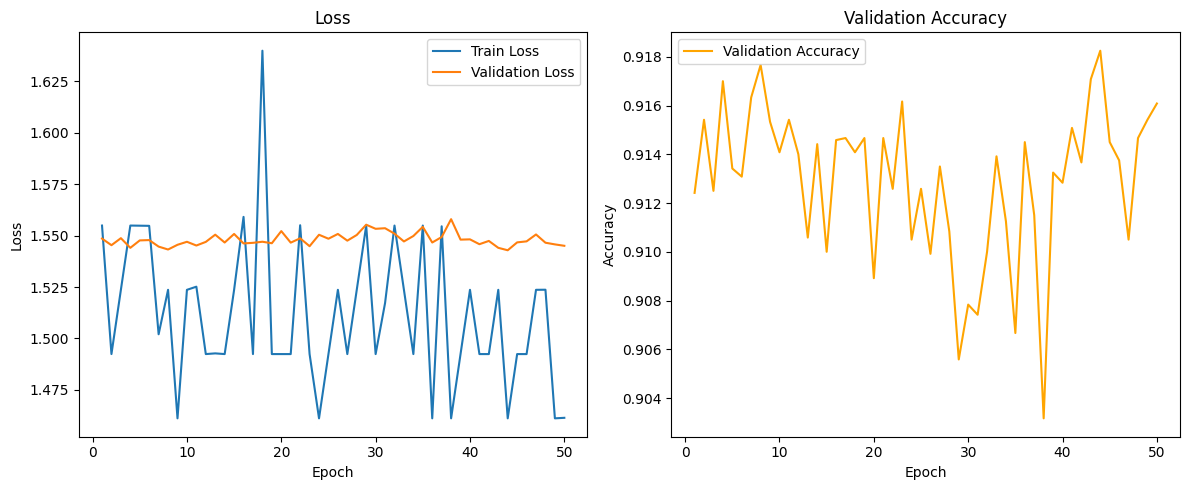

In [58]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_scores, label='Train Loss')
plt.plot(epochs, val_loss_scores, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracy_scores, label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [37]:
#훈련평가
train_loss, train_accuracy = evaluate(model, train_loader, criterion, device)
print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")

#검증평가
test_loss,test_accuracy=evaluate(model,test_loader,criterion,device)
print(f"Loss:{test_loss:.4f}, Accuracy:{test_accuracy:.4f}")

Train Loss: 1.5082, Train Accuracy: 0.9528
Loss:1.5488, Accuracy:0.9119


In [35]:
#일반화 평가
test_dataset=TensorDataset(test_input, test_target)
test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

#평가하기
test_loss,test_accuracy=evaluate(model,test_loader,criterion,device)
print(f"Loss:{test_loss},Accuracy:{test_accuracy}")

Loss:1.5487659781123884,Accuracy:0.9119


In [36]:
#Pandas로 정리하여 보기위해 list로 정리하기
modelResult=[train_accuracy,test_accuracy]
modelResult

[0.9527708333333333, 0.9119]

----
#학습한 모델 저장하기

In [ ]:
#전체 모델 저장
torch.save(model,"../Data/ccn_fsmist.pth")#1.7메가

In [41]:
#전체 모델 불러오기
model1=torch.load("../Data/ccn_fsmist.pth",weights_only=False)

---
#Image 만들어서 예측해보기

In [42]:
from PIL import Image
import numpy as np

In [43]:
#train data의 50번째
abc=np.array(train_data.data[50]).reshape(28,28)
abc.shape

/var/folders/bn/b43j8ymd33x1z80xxsm606h40000gn/T/ipykernel_31159/3345209523.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  abc=np.array(train_data.data[50]).reshape(28,28)


(28, 28)

In [44]:
#Image 만들기
image=Image.fromarray(abc)
image

In [45]:
#image저장
image.save("../Data/fashion_mnist_50.png")

In [47]:
#image불러와서 예측
img=Image.open("../Data/fashion_mnist_50.png")
img

In [48]:
#image를 numpyarray
img=np.array(img)
img=torch.from_numpy(img)
img.shape

torch.Size([28, 28])

In [49]:
#채널 차원 추가 및 정규화
img=img.unsqueeze(0).float()/255.0
img.shape#??

torch.Size([1, 28, 28])

In [50]:
#class들의 이름 정의
classes=['티셔츠','바지','스웨터','드레스','코트','샌달','셔츠','스니커즈','가방','앵글부츠']

In [ ]:
############
#단일 데이터의 예측함수 data_loader=>inputs
def predictOne(model,image,device,classes):
    model.eval()
    with torch.no_grad():
            image = image.to(device)
            outputs=model(image.unsqueeze(0))#차원추가
            _,predicted=torch.max(outputs,1)
            predicted_classes = classes[predicted.item()]#아이템 하나 뽑아옴
    return predicted_classes#종이는 두께까지 3차원, 3차원 세계에는 3차원만 있다.
########

In [53]:
predictOne(model,img,device,classes)#unsqueeze 1인경우만 지움:0인 경우가 많기때문

'드레스'